FACIAL EXPRESSION USING LANDMARKS 

In [53]:
import os
import cv2
import pickle
import numpy as np
import mediapipe as mp
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [61]:
# Set dataset directory
dataset_directory = './dataset/train'

# Get class names (folder names)
class_names = sorted([d for d in os.listdir(dataset_directory) if os.path.isdir(os.path.join(dataset_directory, d))])
print(f"Number of classes: {len(class_names)}\n")

# Count images per class
image_counts = {}
for class_name in class_names:
    class_dir = os.path.join(dataset_directory, class_name)
    count = len([f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))])
    image_counts[class_name] = count

# Print image count per class
for class_name, count in image_counts.items():
    print(f"{class_name}: {count} images")

Number of classes: 3

happy: 1435 images
sad: 1165 images
surprise: 1089 images


GATHER LANDMARK DATA

In [ ]:
# Function to gather landmark data
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1)

landmark_data = {}
for class_name in os.listdir(dataset_directory):
    class_dir = os.path.join(dataset_directory, class_name)
    if not os.path.isdir(class_dir):
        continue

    for filename in os.listdir(class_dir):
        img_path = os.path.join(class_dir, filename)
        img = cv2.imread(img_path) #reads images using OpenCV
        if img is None:
            print(f"Failed to read {img_path}. Skipping...")
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(img_rgb)

        if results.multi_face_landmarks:
            landmarks = results.multi_face_landmarks[0]
            coords = [(landmark.x, landmark.y, landmark.z) for landmark in landmarks.landmark] 
            #Extracts 468 landmark (x, y, z) coordinates.
            landmark_data[img_path] = coords
        else:
            print(f"No face detected in {img_path}. Skipping...")

face_mesh.close()

No face detected in ./dataset/train\happy\happy (1043).jpg. Skipping...
No face detected in ./dataset/train\happy\happy (1238).jpg. Skipping...
No face detected in ./dataset/train\happy\happy (1283).jpg. Skipping...
No face detected in ./dataset/train\happy\happy (1299).jpg. Skipping...
No face detected in ./dataset/train\happy\happy (920).jpg. Skipping...
No face detected in ./dataset/train\sad\sad (10)_1.jpg. Skipping...
No face detected in ./dataset/train\sad\sad (133).jpg. Skipping...
No face detected in ./dataset/train\sad\sad (153).jpg. Skipping...
No face detected in ./dataset/train\sad\sad (155).jpg. Skipping...
No face detected in ./dataset/train\sad\sad (22)_1.jpg. Skipping...
No face detected in ./dataset/train\sad\sad (225).jpg. Skipping...
No face detected in ./dataset/train\sad\sad (268).jpg. Skipping...
No face detected in ./dataset/train\sad\sad (28)_1.jpg. Skipping...
No face detected in ./dataset/train\sad\sad (5)_1.jpg. Skipping...
No face detected in ./dataset/train

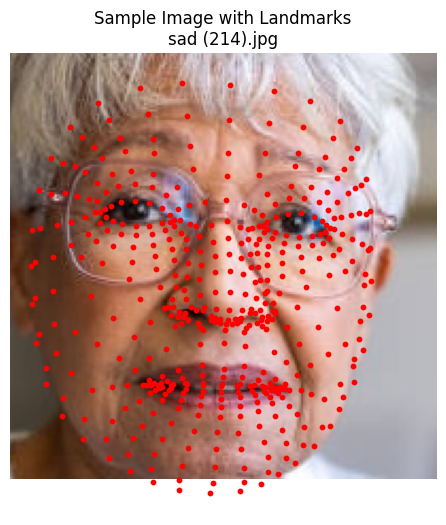

In [83]:
#for printing sample image with landmark
import random
sample_path = random.choice(list(landmark_data.keys())) if landmark_data else None

if sample_path:
    img = cv2.imread(sample_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    coords = landmark_data[sample_path]

    # Plot image and landmarks
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    xs = [x * img.shape[1] for x, y, z in coords]
    ys = [y * img.shape[0] for x, y, z in coords]
    plt.scatter(xs, ys, s=10, c='red')  # plot landmarks
    plt.title(f"Sample Image with Landmarks\n{os.path.basename(sample_path)}")
    plt.axis('off')
    plt.show()

In [44]:
# Save landmark data to file
landmark_pkl = 'mp_landmark_data.pkl'
with open(landmark_pkl, 'wb') as f:
    pickle.dump(landmark_data, f)
print(f"Landmark data saved to {landmark_pkl}.")

Landmark data saved to mp_landmark_data.pkl.


LOAD LANDMARK DATA FOR TRAINING

In [ ]:
# Load landmark data
with open(landmark_pkl, 'rb') as f:
    data_dict = pickle.load(f)

# Convert the landmark data to NumPy array and flattened to a 1D array
data = []
labels = []

for img_path, landmarks in data_dict.items():
    data.append(np.array(landmarks).flatten())
    labels.append(os.path.normpath(img_path).split(os.sep)[-2])

data = np.asarray(data)
labels = np.asarray(labels)

# Output shape of data
print("Data Shape:", data.shape)
print("Labels Shape:", labels.shape)

Data Shape: (3647, 1404)
Labels Shape: (3647,)


TRAINING MODEL

In [ ]:
# Encode the labels
label_encoder = LabelEncoder()
label_encoder.fit(labels)
label_classes = label_encoder.classes_

# Save label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print("\nLabel encoder saved as 'label_encoder.pkl'.")

# Convert labels to categorical 
labels_encoded = label_encoder.transform(labels)
labels_categorical = to_categorical(labels_encoded)

# Split data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(
    data, labels_categorical, test_size=0.2, stratify=labels_encoded, random_state=42
)

# Output data split sizes
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)


Label encoder saved as 'label_encoder.pkl'.
Training data shape: (2917, 1404)
Test data shape: (730, 1404)


In [50]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(x_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(len(label_classes), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=30, batch_size=32, validation_split=0.2)

Epoch 1/30


c:\Users\vsmmc\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3500 - loss: 1.1932 - val_accuracy: 0.5582 - val_loss: 1.0370
Epoch 2/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5267 - loss: 0.9899 - val_accuracy: 0.6575 - val_loss: 0.8388
Epoch 3/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6664 - loss: 0.7934 - val_accuracy: 0.6918 - val_loss: 0.6583
Epoch 4/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7114 - loss: 0.6625 - val_accuracy: 0.7774 - val_loss: 0.5689
Epoch 5/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7528 - loss: 0.5728 - val_accuracy: 0.6575 - val_loss: 0.7285
Epoch 6/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7444 - loss: 0.5951 - val_accuracy: 0.8065 - val_loss: 0.4877
Epoch 7/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7761 - loss: 0.5446 - val_accuracy: 0.7740 - val_loss: 0.5037
Epoch 8/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7883 - loss: 0.4988 - val_accuracy: 0.8048 - val_loss: 0.4742
Epo

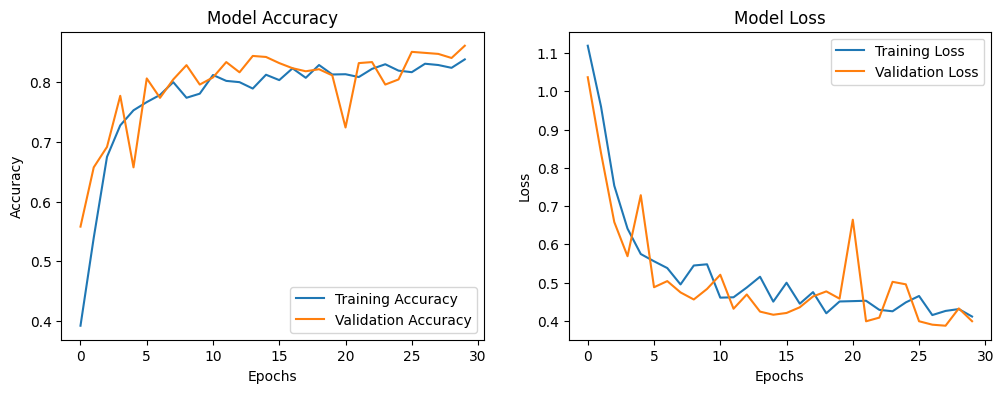

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Test Accuracy: 80.96%

Classification Report:
               precision    recall  f1-score   support

       happy       0.79      0.93      0.86       286
         sad       0.74      0.71      0.73       228
    surprise       0.93      0.75      0.83       216

    accuracy                           0.81       730
   macro avg       0.82      0.80      0.80       730
weighted avg       0.82      0.81      0.81       730


Confusion Matrix:
 [[267  16   3]
 [ 55 163  10]
 [ 15  40 161]]


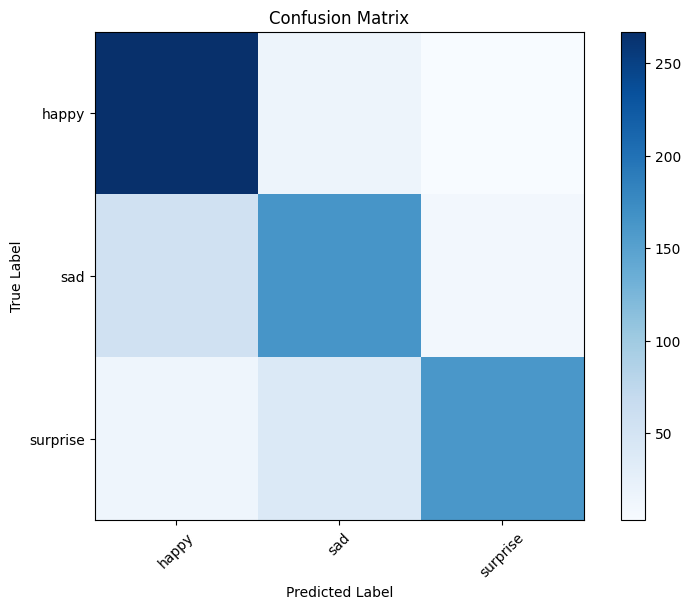

In [80]:

# Plot training history (accuracy and loss)
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluate the model
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Calculate accuracy and print classification report and confusion matrix
acc = accuracy_score(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=label_classes)
cm = confusion_matrix(y_true, y_pred)

# Output results
print(f"\nTest Accuracy: {acc * 100:.2f}%")
print("\nClassification Report:\n", report)
print("\nConfusion Matrix:\n", cm) 


# Plot confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(label_classes))
plt.xticks(tick_marks, label_classes, rotation=45)
plt.yticks(tick_marks, label_classes)

plt.tight_layout()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



In [ ]:
model.save('mp_sequential_model.h5')
print("\nModel saved as 'mp_sequential_model.h5'.")